# NGC 1068 fluctuated Case 3: CPL + CPL

Explicit NGC 4151-style spectral fitting and SED workflow.


In [1]:
from pathlib import Path
import json

import sys
UTILS_DIR = Path(r"/Users/parshadkp/Software/cosipy/docs/tutorials/spectral_fits/continuum_fit/AGN/Fluctuate_True")
if str(UTILS_DIR) not in sys.path:
    sys.path.insert(0, str(UTILS_DIR))


import astropy.units as u
from astropy.coordinates import SkyCoord
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display
from astromodels import Cutoff_powerlaw, Line, Model, PointSource, Powerlaw
from threeML import DataList, JointLikelihood

from cosipy.event_selection import GoodTimeInterval
from agn_cosi_fit_utils import (
    COSIPlugin, cosi_source_detection_ts, fit_cosi_exposure_from_results,
    load_agn_manifest_histograms, make_cosi_background_parameter,
    model_improvement_ts, open_spacecraft_history, save_agn_fit_summary,
    scale_spacecraft_livetime,
)
from agn_sed_ensemble import (
    classify_representative_sed, ensemble_summary_to_sed_dataframe,
    fit_representative_sed, run_or_load_manifest_sed_ensemble,
)

SED_KEV_TO_ERG = u.keV.to(u.erg)
KEV_TO_MEV = u.keV.to(u.MeV)
%matplotlib inline


20:40:27 WARNING   The naima package is not available. Models that depend on it will not be         ]8;id=43336;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=650039;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py#43\43]8;;\
                  available                                                                                        

         WARNING   The GSL library or the pygsl wrapper cannot be loaded. Models that depend on it  ]8;id=165786;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=92265;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py#65\65]8;;\
                  will not be available.                                                                           

         WARNING   The ebltable package is not available. Models that depend on it will not be     ]8;id=941684;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/absorption.py\absorption.py]8;;\:]8;id=485926;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/absorption.py#33\33]8;;\
                  available                                                                                        

20:40:27 INFO      Starting 3ML!                                                                     ]8;id=265824;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=340157;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#44\44]8;;\

         WARNING   WARNINGs here are NOT errors                                                      ]8;id=100626;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=607;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#45\45]8;;\

...

         WARNING   Could not import plugin FermiLATLike.py. Do you have the relative instrument     ]8;id=336383;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=106360;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#126\126]8;;\
                  software installed and configured?                                                               

         WARNING   No fermitools installed                                              ]8;id=750309;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py\lat_transient_builder.py]8;;\:]8;id=724897;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py#44\44]8;;\

         WARNING   Env. variable OMP_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=148438;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=757035;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable MKL_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=269681;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=71210;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable NUMEXPR_NUM_THREADS is not set. Please set it to 1 for optimal     ]8;id=333770;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=542839;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

# Model and input files


In [2]:
MANIFEST_24M_PATH = Path(r"/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/GammaRay/Paper_Models/Fluctuate_True/Sensitivity_Ensemble/NGC1068_Case3/NGC1068_Case3_CPL_CPL_median_realization_24months.json")
MANIFEST_3M_PATH = Path(r"/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/GammaRay/Paper_Models/Fluctuate_True/Sensitivity_Ensemble/NGC1068_Case3/NGC1068_Case3_CPL_CPL_companion_from_24months_realization_3months.json")
BACKGROUND_PSEUDOCOUNT = 1e-12
SED_ENSEMBLE_RECOMPUTE = False
N_SED_BINS = 10

PLOT_DIR = Path(r"/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/Papers/AGN_Corona_EC_Overleaf/Plots/Fluctuate_True")
FIT_SUMMARY_DIR = Path(r"/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/Papers/AGN_Corona_EC_Overleaf/Fits/Fluctuate_True")
PLOT_DIR.mkdir(parents=True, exist_ok=True)
FIT_SUMMARY_DIR.mkdir(parents=True, exist_ok=True)


In [3]:
with MANIFEST_24M_PATH.open() as stream:
    manifest_24m = json.load(stream)
case = manifest_24m.get("resolved_case_at_threshold", manifest_24m.get("resolved_case"))
if case is None:
    raise KeyError("Manifest has no resolved spectral case")

required_realization_files = [
    Path(manifest_24m["source_expectation_file"]),
    Path(manifest_24m["median_data_file"]),
]
missing_realization_files = [path for path in required_realization_files if not path.exists()]
if missing_realization_files:
    missing_text = "\n".join(str(path) for path in missing_realization_files)
    raise FileNotFoundError(
        "The manifest exists, but its HDF5 realization files are missing. "
        "Rerun the corresponding NGC 1068 sensitivity notebook first:\n"
        + missing_text
    )

manifest_24m, source_expectation_24m, data_24m, background_24m = load_agn_manifest_histograms(
    MANIFEST_24M_PATH, manifest_24m["background_file_3m"], 24,
)
dr = manifest_24m["response_file"]

source_coord = SkyCoord(
    l=float(case["longitude_deg"]), b=float(case["latitude_deg"]),
    frame="galactic", unit="deg",
)
full_orientation = open_spacecraft_history(manifest_24m["orientation_file_3m"])
source_gti = GoodTimeInterval.from_pointing_cut(
    source_coord, full_orientation, float(case.get("fov_cut_deg", 60.0))*u.deg,
    earth_occ=False,
)
orientation_3m = full_orientation.apply_gti(source_gti)
orientation_24m = scale_spacecraft_livetime(orientation_3m, 8.0)

print("Description:", case["description"])
print("Representative seed:", manifest_24m["representative_seed"])
print("Source file:", manifest_24m["source_expectation_file"])
print("Data file:", manifest_24m["median_data_file"])


Description: NGC 1068 Case 3: thermal CPL Ec=128 keV plus CPL Ec=3750 keV
Representative seed: 107094
Source file: /Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/GammaRay/Paper_Models/Fluctuate_True/Sensitivity_Ensemble/NGC1068_Case3/NGC1068_ec_128_DC4_COSI_cpl_cpl_60_fovCut_24months_medianSeed_107094.hdf5
Data file: /Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/GammaRay/Paper_Models/Fluctuate_True/Sensitivity_Ensemble/NGC1068_Case3/NGC1068_plus_bkg_ec_128_DC4_COSI_cpl_cpl_60_fovCut_24months_medianSeed_107094.hdf5


# Source model


In [4]:
def repivot_k(specification, pivot_keV):
    return float(
        specification["K"]
        * (float(pivot_keV) / float(specification["pivot_keV"]))
        ** float(specification["index"])
    )

def make_shape(specification, *, fit, pivot_keV=None):
    kind = specification["kind"]
    pivot = float(specification["pivot_keV"] if pivot_keV is None else pivot_keV)
    normalization = repivot_k(specification, pivot)
    if kind == "cpl":
        shape = Cutoff_powerlaw()
        shape.xc.value = float(specification["cutoff_keV"])
        shape.xc.unit = u.keV
        if fit:
            shape.xc.min_value = float(specification.get("cutoff_min_keV", 100.0))
            shape.xc.max_value = float(specification.get("cutoff_max_keV", 10000.0))
            shape.xc.fix = not bool(specification.get("fit_cutoff_free", True))
    elif kind == "pl":
        shape = Powerlaw()
    else:
        raise ValueError(f"Unsupported component: {kind}")
    shape.K.value = normalization
    shape.K.unit = u.keV**-1 * u.cm**-2 * u.s**-1
    shape.piv.value = pivot
    shape.piv.unit = u.keV
    shape.index.value = float(specification["index"])
    if fit:
        shape.K.min_value = float(specification.get("K_min", 1e-10))
        shape.K.max_value = float(specification.get("K_max", 1.0))
        shape.index.min_value = float(specification.get("index_min", -5.0))
        shape.index.max_value = float(specification.get("index_max", 1.0))
        shape.index.fix = not bool(specification.get("fit_index_free", kind == "pl"))
    return shape

fit_pivot_keV = float(case.get("fit_pivot_keV", 200.0))
primary_injected = make_shape(case["primary"], fit=False)
secondary_injected = None
injected_shape = primary_injected
if case.get("secondary") is not None:
    secondary_injected = make_shape(case["secondary"], fit=False)
    injected_shape = primary_injected + secondary_injected

primary_fit = make_shape(case["primary"], fit=True, pivot_keV=fit_pivot_keV)
fit_shape = primary_fit
secondary_fit = None
link_function = None
if case.get("secondary") is not None:
    secondary_fit = make_shape(case["secondary"], fit=True, pivot_keV=fit_pivot_keV)
    fit_shape = primary_fit + secondary_fit

source_name = str(case.get("source_name", "NGC1068"))
source = PointSource(
    source_name, l=float(case["longitude_deg"]), b=float(case["latitude_deg"]),
    spectral_shape=fit_shape,
)
model = Model(source)
if secondary_fit is not None:
    injected_link_ratio = repivot_k(case["secondary"], fit_pivot_keV) / repivot_k(case["primary"], fit_pivot_keV)
    link_function = Line(a=0.0, b=injected_link_ratio)
    link_function.a.fix = True
    link_function.b.min_value = 0.0
    model.link(
        model[source_name].spectrum.main.composite.K_2,
        model[source_name].spectrum.main.composite.K_1,
        link_function,
    )
    print("Injected linked K ratio:", injected_link_ratio)

print(model.display())


Injected linked K ratio: 0.12931787935796998


Model summary:
==============

                  N
Point sources     1
Extended sources  0
Particle sources  0

Free parameters (5):
--------------------

                                            value min_value max_value  \
NGC1068.spectrum.main.composite.K_1      0.000015       0.0       1.0   
NGC1068.spectrum.main.composite.xc_1        128.0      10.0    2000.0   
NGC1068...b                              0.129318       0.0      None   
NGC1068.spectrum.main.composite.index_2     -1.85      -5.0       1.0   
NGC1068.spectrum.main.composite.xc_2       3750.0    1000.0   10000.0   

                                                   unit  
NGC1068.spectrum.main.composite.K_1      keV-1 s-1 cm-2  
NGC1068.spectrum.main.composite.xc_1                keV  
NGC1068...b                                              
NGC1068.spectrum.main.composite.index_2                  
NGC1068.spectrum.main.composite.xc_2                keV  

Fixed parameters (6):
(abridged. Use complete=True to see all fixed parameters)


Properties (0):
--------------------

(none)


Linked parameters (1):
----------------------

               NGC1068.spectrum.main.composite.K_2
linked to      NGC1068.spectrum.main.composite.K_1
function                                      Line
current value                             0.000002
unit                               1 / (keV s cm2)


Independent variables:
----------------------

(none)

Linked functions (0):
----------------------

(none)

None


# Spectral fitting


In [5]:
background_parameter = make_cosi_background_parameter("cosi_24m")
cosi = COSIPlugin(
    "cosi_24m", dr=dr,
    data=data_24m.project("Em", "Phi", "PsiChi"),
    bkg=background_24m.project("Em", "Phi", "PsiChi"),
    sc_orientation=orientation_24m, nuisance_param=background_parameter,
    background_pseudocount=BACKGROUND_PSEUDOCOUNT, earth_occ=True,
)
cosi.set_model(model)
like = JointLikelihood(model, DataList(cosi), verbose=False)
like.fit()
TS_24m, null_24m = cosi_source_detection_ts(like, cosi)
print("24-month source TS:", TS_24m)
display(like.results.get_data_frame())


20:40:54 INFO      set the minimizer to minuit                                             ]8;id=110610;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=445091;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

20:41:13 WARNING   6.9 percent of samples have been thrown away because they failed the    ]8;id=292715;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/analysis_results.py\analysis_results.py]8;;\:]8;id=685425;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/analysis_results.py#1645\1645]8;;\
                  constraints on the parameters. This results might not be suitable for                            
                  error propagation. Enlarge the boundaries until you loose less than 1                            
                  percent of the samples.                                                                          

20:41:13 WARNING   The current value of the parameter xc_2 (10.0) was below the new minimum        ]8;id=67398;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=742181;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#732\732]8;;\
                  1000.0.                                                                                          

Best fit values:

,result,unit
parameter,,
NGC1068.spectrum.main.composite.K_1,(1.44 -0.10 +0.11) x 10^-5,1 / (keV s cm2)
NGC1068.spectrum.main.composite.xc_1,(1.54 -0.13 +0.14) x 10^2,keV
NGC1068.spectrum.main.composite.K_2.Line.b,(7.8 +/- 2.9) x 10^-2,
NGC1068.spectrum.main.composite.index_2,-1.4 +/- 0.4,
NGC1068.spectrum.main.composite.xc_2,(2.6 -1.2 +2.1) x 10^3,keV
background_cosi_24m,(2.48988 +/- 0.00017) x 10,Hz


...

,-log(likelihood)
cosi_24m,-3794640074.995757
total,-3794640074.995757


Values of statistical measures:

,statistical measures
AIC,-7589280137.99115
BIC,-7589280075.906081


24-month source TS: 3953.2449321746826


,value,negative_error,positive_error,error,unit
NGC1068.spectrum.main.composite.K_1,0.000014,-0.000001,0.000001,0.000001,1 / (keV s cm2)
NGC1068.spectrum.main.composite.xc_1,153.910210,-12.603883,12.334778,12.469331,keV
NGC1068.spectrum.main.composite.K_2.Line.b,0.078230,-0.023800,0.028135,0.025967,
NGC1068.spectrum.main.composite.index_2,-1.444559,-0.361238,0.300401,0.330819,
NGC1068.spectrum.main.composite.xc_2,2577.548861,-1015.841217,2049.450170,1532.645694,keV
background_cosi_24m,24.898764,-0.001702,0.001690,0.001696,Hz


## Nested-model comparison


In [6]:
like_primary = None
delta_ts_24m = None
if case.get("secondary") is not None:
    primary_only_shape = make_shape(case["primary"], fit=True, pivot_keV=fit_pivot_keV)
    primary_only_source = PointSource(
        source_name + "_primary_only",
        l=float(case["longitude_deg"]), b=float(case["latitude_deg"]),
        spectral_shape=primary_only_shape,
    )
    primary_only_model = Model(primary_only_source)
    primary_only_plugin = COSIPlugin(
        "cosi_primary_only_24m", dr=dr,
        data=data_24m.project("Em", "Phi", "PsiChi"),
        bkg=background_24m.project("Em", "Phi", "PsiChi"),
        sc_orientation=orientation_24m,
        nuisance_param=make_cosi_background_parameter("cosi_primary_only_24m"),
        background_pseudocount=BACKGROUND_PSEUDOCOUNT, earth_occ=True,
    )
    primary_only_plugin.set_model(primary_only_model)
    like_primary = JointLikelihood(primary_only_model, DataList(primary_only_plugin), verbose=False)
    like_primary.fit()
    delta_ts_24m = model_improvement_ts(like_primary, like)
    print("24-month full model versus CPL-only Delta TS:", delta_ts_24m)


         INFO      set the minimizer to minuit                                             ]8;id=887970;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=739032;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

Best fit values:

,result,unit
parameter,,
NGC1068_primary_only...K,(8.6 +/- 0.4) x 10^-6,1 / (keV s cm2)
NGC1068_primary_only...xc,(3.46 -0.19 +0.20) x 10^2,keV
background_cosi_primary_only_24m,(2.49040 +/- 0.00016) x 10,Hz


Correlation matrix:

1.00,-0.90,-0.10
-0.90,1.00,-0.21
-0.10,-0.21,1.00


Values of -log(likelihood) at the minimum:

,-log(likelihood)
cosi_primary_only_24m,-3794639974.763398
total,-3794639974.763398


Values of statistical measures:

,statistical measures
AIC,-7589279943.526692
BIC,-7589279912.484079


24-month full model versus CPL-only Delta TS: 200.46471786499023


## Three- and 24-month results


In [7]:
like_3m = None
TS_3m = None
delta_ts_3m = None
if MANIFEST_3M_PATH is not None:
    manifest_3m, source_expectation_3m, data_3m, background_3m = load_agn_manifest_histograms(
        MANIFEST_3M_PATH, manifest_24m["background_file_3m"], 3,
    )
    like_3m, cosi_3m = fit_cosi_exposure_from_results(
        reference_results=like.results, data_hist=data_3m, background_hist=background_3m,
        dr_path=dr, sc_orientation=orientation_3m, dataset_name="cosi_3m",
        background_pseudocount=BACKGROUND_PSEUDOCOUNT,
    )
    TS_3m, _ = cosi_source_detection_ts(like_3m, cosi_3m)
    print("3-month source TS:", TS_3m)
    if like_primary is not None:
        like_primary_3m, _ = fit_cosi_exposure_from_results(
            reference_results=like_primary.results, data_hist=data_3m, background_hist=background_3m,
            dr_path=dr, sc_orientation=orientation_3m, dataset_name="cosi_primary_only_3m",
            background_pseudocount=BACKGROUND_PSEUDOCOUNT,
        )
        delta_ts_3m = model_improvement_ts(like_primary_3m, like_3m)
        print("3-month full model versus CPL-only Delta TS:", delta_ts_3m)


20:41:43 WARNING   The current value of the parameter xc_2 (10.0) was below the new minimum        ]8;id=537289;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=11287;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#732\732]8;;\
                  1000.0.                                                                                          

         WARNING   The current value of the parameter xc_2 (10.0) was below the new minimum        ]8;id=44333;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=319997;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#732\732]8;;\
                  1000.0.                                                                                          

20:41:43 INFO      set the minimizer to minuit                                             ]8;id=576928;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=202195;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

20:41:58 WARNING   65.5 percent of samples have been thrown away because they failed the   ]8;id=344396;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/analysis_results.py\analysis_results.py]8;;\:]8;id=82525;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/analysis_results.py#1645\1645]8;;\
                  constraints on the parameters. This results might not be suitable for                            
                  error propagation. Enlarge the boundaries until you loose less than 1                            
                  percent of the samples.                                                                          

20:41:58 WARNING   The current value of the parameter xc_2 (10.0) was below the new minimum        ]8;id=596371;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=944353;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#732\732]8;;\
                  1000.0.                                                                                          

3-month source TS: 428.38267838954926


         INFO      set the minimizer to minuit                                             ]8;id=208426;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=166844;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

3-month full model versus CPL-only Delta TS: 12.65615701675415


In [8]:
fit_results = {"24m_case3": like.results}
injected_models = {"24m_case3": {"total": injected_shape}}
ts_values = {"24m_case3": TS_24m}
exposures = {"24m_case3": 24}
extra_statistics = {}
if delta_ts_24m is not None:
    extra_statistics["24m_case3"] = {"Delta_TS_full_vs_CPL": delta_ts_24m}
if like_3m is not None:
    fit_results["3m_case3"] = like_3m.results
    injected_models["3m_case3"] = {"total": injected_shape}
    ts_values["3m_case3"] = TS_3m
    exposures["3m_case3"] = 3
    if delta_ts_3m is not None:
        extra_statistics["3m_case3"] = {"Delta_TS_full_vs_CPL": delta_ts_3m}
fit_summary_path = save_agn_fit_summary(
    output_path=FIT_SUMMARY_DIR / "NGC1068_Case3_CPL_CPL_global_fit_summary_3_24Months.txt",
    fit_results=fit_results, injected_models=injected_models,
    ts_values=ts_values, exposure_months=exposures,
    extra_statistics=extra_statistics,
    notes="Explicit NGC 4151-style fit using the exact zero-source null.",
)
print("Saved:", fit_summary_path)


Saved: /Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/Papers/AGN_Corona_EC_Overleaf/Fits/Fluctuate_True/NGC1068_Case3_CPL_CPL_global_fit_summary_3_24Months.txt


## Global-fit plot


In [9]:
results = like.results
optimized_shape = results.optimized_model[source_name].spectrum.main.shape

def variate_or_value(parameter):
    if parameter.path in results.optimized_model.free_parameters:
        return results.get_variates(parameter.path)
    return float(parameter.value)

if optimized_shape.__class__.__name__ == "Cutoff_powerlaw":
    pivot = float(optimized_shape.piv.value)
    def evaluate_total(energy, K, xc, index):
        return K * (energy/pivot)**index * np.exp(-energy/xc)
    propagated_flux = results.propagate(
        evaluate_total, K=variate_or_value(optimized_shape.K),
        xc=variate_or_value(optimized_shape.xc),
        index=variate_or_value(optimized_shape.index),
    )
else:
    thermal_shape, tail_shape = optimized_shape.functions[:2]
    link_b = tail_shape.K.auxiliary_variable[1].b
    pivot_1 = float(thermal_shape.piv.value)
    pivot_2 = float(tail_shape.piv.value)
    if tail_shape.__class__.__name__ == "Powerlaw":
        def evaluate_total(energy, K_1, xc_1, index_1, b, index_2):
            thermal = K_1*(energy/pivot_1)**index_1*np.exp(-energy/xc_1)
            nonthermal = (b*K_1)*(energy/pivot_2)**index_2
            return thermal + nonthermal
        propagated_flux = results.propagate(
            evaluate_total, K_1=variate_or_value(thermal_shape.K),
            xc_1=variate_or_value(thermal_shape.xc),
            index_1=variate_or_value(thermal_shape.index),
            b=variate_or_value(link_b), index_2=variate_or_value(tail_shape.index),
        )
    else:
        def evaluate_total(energy, K_1, xc_1, index_1, b, xc_2, index_2):
            thermal = K_1*(energy/pivot_1)**index_1*np.exp(-energy/xc_1)
            nonthermal = (b*K_1)*(energy/pivot_2)**index_2*np.exp(-energy/xc_2)
            return thermal + nonthermal
        propagated_flux = results.propagate(
            evaluate_total, K_1=variate_or_value(thermal_shape.K),
            xc_1=variate_or_value(thermal_shape.xc),
            index_1=variate_or_value(thermal_shape.index), b=variate_or_value(link_b),
            xc_2=variate_or_value(tail_shape.xc),
            index_2=variate_or_value(tail_shape.index),
        )

energy = np.geomspace(100.0, 10000.0, 160)
flux_injected = np.asarray([injected_shape.evaluate_at(e) for e in energy], dtype=float)
flux_median = np.zeros_like(energy)
flux_low = np.zeros_like(energy)
flux_high = np.zeros_like(energy)
for i, e in enumerate(energy):
    distribution = propagated_flux(float(e))
    flux_median[i] = float(distribution.median)
    flux_low[i], flux_high[i] = distribution.equal_tail_interval(cl=0.68)


20:42:07 WARNING   The current value of the parameter xc_2 (10.0) was below the new minimum        ]8;id=788045;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=896441;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#732\732]8;;\
                  1000.0.                                                                                          

         WARNING   The current value of the parameter xc_2 (10.0) was below the new minimum        ]8;id=682857;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=110550;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#732\732]8;;\
                  1000.0.                                                                                          

         WARNING   The current value of the parameter xc_2 (10.0) was below the new minimum        ]8;id=563925;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=969881;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#732\732]8;;\
                  1000.0.                                                                                          

         WARNING   The current value of the parameter xc_2 (10.0) was below the new minimum        ]8;id=251257;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=524473;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#732\732]8;;\
                  1000.0.                                                                                          

         WARNING   The current value of the parameter xc_2 (10.0) was below the new minimum        ]8;id=583088;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=718592;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#732\732]8;;\
                  1000.0.                                                                                          

         WARNING   The current value of the parameter xc_2 (10.0) was below the new minimum        ]8;id=766258;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=723123;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#732\732]8;;\
                  1000.0.                                                                                          

         WARNING   The current value of the parameter xc_2 (10.0) was below the new minimum        ]8;id=386649;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=88717;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#732\732]8;;\
                  1000.0.                                                                                          

In [10]:
FONT_SIZE = 25
FIGURE_SIZE = (12, 9)

plt.rcParams["agg.path.chunksize"] = 10000
plt.rcParams.update({
    "font.size": FONT_SIZE,
    "font.family": "Times New Roman",
    "font.weight": "550",
    "axes.linewidth": 1.5,
    "axes.labelsize": FONT_SIZE,
    "axes.labelweight": "550",
    "axes.titleweight": "550",
    "xtick.labelsize": FONT_SIZE,
    "ytick.labelsize": FONT_SIZE,
    "legend.fontsize": FONT_SIZE,
})

def style_axis(axis, *, show_ylabel=True):
    axis.tick_params(
        axis="x", which="major", size=12, width=1.5, direction="in",
        top=True, bottom=True, pad=8, labelsize=FONT_SIZE,
    )
    axis.tick_params(
        axis="x", which="minor", size=6, width=1.5, direction="in",
        top=True, bottom=True,
    )
    axis.tick_params(
        axis="y", which="major", size=12, width=1.5, direction="in",
        left=True, right=True, pad=8, labelsize=FONT_SIZE,
    )
    axis.tick_params(
        axis="y", which="minor", size=6, width=1.5, direction="in",
        left=True, right=True,
    )
    for spine in axis.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.5)
    axis.set_xscale("log")
    axis.set_yscale("log")
    axis.set_xlim(0.085, 12.0)
    axis.set_xlabel("Energy (MeV)", fontsize=FONT_SIZE, fontweight="550")
    axis.set_ylabel(
        r"Energy Flux (erg cm$^{-2}$ s$^{-1}$)" if show_ylabel else "",
        fontsize=FONT_SIZE, fontweight="550",
    )

def draw_global_curves(axis):
    axis.plot(
        energy*KEV_TO_MEV, SED_KEV_TO_ERG*energy**2*flux_injected,
        color="#D55E00", ls=":", lw=3,
    )
    axis.plot(
        energy*KEV_TO_MEV, SED_KEV_TO_ERG*energy**2*flux_median,
        color="#D55E00", lw=2,
    )
    axis.fill_between(
        energy*KEV_TO_MEV, SED_KEV_TO_ERG*energy**2*flux_low,
        SED_KEV_TO_ERG*energy**2*flux_high, color="#D55E00", alpha=0.18,
    )


Saved: /Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/Papers/AGN_Corona_EC_Overleaf/Plots/Fluctuate_True/NGC1068_Case3_CPL_CPL_128_24Months_GlobalFit.pdf


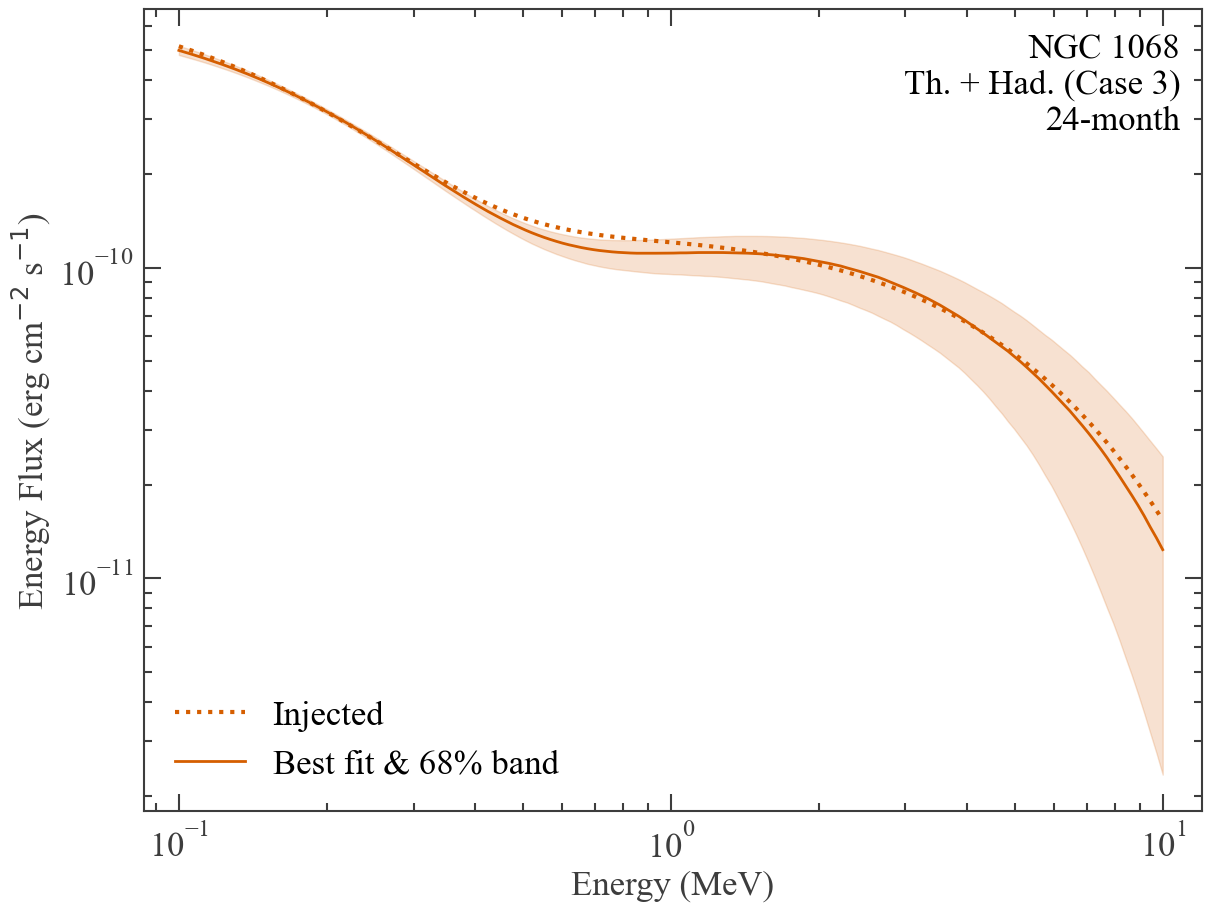

In [11]:
fig_global, ax_global = plt.subplots(figsize=FIGURE_SIZE, constrained_layout=True)
style_axis(ax_global)
draw_global_curves(ax_global)
ax_global.text(0.98, 0.97, "NGC 1068\nTh. + Had. (Case 3)\n24-month", transform=ax_global.transAxes, ha="right", va="top", fontsize=FONT_SIZE, fontweight="550")
ax_global.legend(handles=[
    plt.Line2D([], [], color="#D55E00", ls=":", lw=3, label="Injected"),
    plt.Line2D([], [], color="#D55E00", lw=2, label="Best fit & 68% band"),
], fontsize=FONT_SIZE, loc="lower left", frameon=False)
global_plot_path = PLOT_DIR / "NGC1068_Case3_CPL_CPL_128_24Months_GlobalFit.pdf"
# The global-fit figure is displayed for inspection but intentionally not saved.
plt.show()


# SED


In [12]:
representative_sed = fit_representative_sed(
    source_expectation=source_expectation_24m,
    background_expectation=background_24m, data_histogram=data_24m,
    injected_shape=injected_shape, n_sed_bins=N_SED_BINS,
    energy_min_keV=100.0, energy_max_keV=10000.0,
    background_pseudocount=BACKGROUND_PSEUDOCOUNT, detection_ts=4.0,
)
representative_sed = classify_representative_sed(representative_sed, detection_ts=4.0)

_, ensemble_summary, _, ensemble_summary_file = run_or_load_manifest_sed_ensemble(
    manifest=manifest_24m, source_expectation=source_expectation_24m,
    background_expectation=background_24m, injected_shape=injected_shape,
    n_sed_bins=N_SED_BINS, energy_min_keV=100.0, energy_max_keV=10000.0,
    background_pseudocount=BACKGROUND_PSEUDOCOUNT,
    recompute=SED_ENSEMBLE_RECOMPUTE, detection_ts=4.0, expected_seed_count=300,
)
ensemble_sed = ensemble_summary_to_sed_dataframe(ensemble_summary)

display(representative_sed[["bin_index", "ts_value", "plot_role", "excess_counts"]])
display(ensemble_summary[["bin_index", "ts_median", "plot_role", "fraction_ts_zero"]])


,bin_index,ts_value,plot_role,excess_counts
0,1,1732.409375,detection,297285.0
1,2,2988.251849,detection,489805.0
2,3,1442.156732,detection,279752.0
3,4,427.055444,detection,109930.0
4,5,142.540409,detection,51722.0
5,6,70.439328,detection,11479.0
6,7,122.437921,detection,16226.0
7,8,43.341688,detection,2478.0
8,9,76.948295,detection,-195.0
9,10,37.255090,detection,476.0


,bin_index,ts_median,plot_role,fraction_ts_zero
0,1,1818.508149,detection,0.000000
1,2,2917.451447,detection,0.000000
2,3,1383.345519,detection,0.000000
3,4,420.116831,detection,0.000000
4,5,130.595914,detection,0.000000
5,6,38.845992,detection,0.000000
6,7,11.751200,detection,0.000000
7,8,47.142551,detection,0.133333
8,9,80.049749,detection,0.103333
9,10,34.789187,upper_limit,0.386667


In [13]:
def plot_sed_dataframe(sed_dataframe, save_path=None):
    roles = sed_dataframe["plot_role"].astype(str)
    detections = sed_dataframe.loc[roles == "detection"]
    upper_limits = sed_dataframe.loc[roles == "upper_limit"]
    def xerr(frame):
        return KEV_TO_MEV*np.vstack([
            frame["e_ref_keV"]-frame["e_min_keV"],
            frame["e_max_keV"]-frame["e_ref_keV"],
        ])
    fig, axis = plt.subplots(figsize=FIGURE_SIZE, constrained_layout=True)
    style_axis(axis); draw_global_curves(axis)
    if not detections.empty:
        y = detections["sed_erg_cm2_s"].to_numpy(float)
        axis.errorbar(
            detections["e_ref_keV"]*KEV_TO_MEV, y, xerr=xerr(detections),
            yerr=np.vstack([
                np.maximum(y-detections["sed_lo_erg_cm2_s"], 0.0),
                np.maximum(detections["sed_hi_erg_cm2_s"]-y, 0.0),
            ]), fmt="o", color="#D55E00", markerfacecolor="white",
            markeredgewidth=1.6, capsize=4, markersize=8,
        )
    if not upper_limits.empty:
        if "sed_ul95_erg_cm2_s" in upper_limits:
            y = upper_limits["sed_ul95_erg_cm2_s"].to_numpy(float)
        elif "sed_ul95_median_erg_cm2_s" in upper_limits:
            y = upper_limits["sed_ul95_median_erg_cm2_s"].to_numpy(float)
        else:
            y = upper_limits["sed_hi_erg_cm2_s"].to_numpy(float)
        axis.errorbar(
            upper_limits["e_ref_keV"]*KEV_TO_MEV, y, xerr=xerr(upper_limits),
            yerr=np.maximum(0.5*y, np.finfo(float).tiny), uplims=True, fmt="v",
            color="#D55E00", markerfacecolor="white", markeredgewidth=1.8,
            elinewidth=2.4, capsize=6, markersize=11,
        )
    axis.text(0.98, 0.97, "NGC 1068\nTh. + Had. (Case 3)\n24-month", transform=axis.transAxes, ha="right", va="top", fontsize=FONT_SIZE, fontweight="550")
    handles=[
        plt.Line2D([], [], color="#D55E00", ls=":", lw=3, label="Injected"),
        plt.Line2D([], [], color="#D55E00", lw=2, label="Best fit & 68% band"),
        plt.Line2D([], [], color="0.25", marker="o", markerfacecolor="white", linestyle="None", label="COSI SED"),
        plt.Line2D([], [], color="0.25", marker="v", markerfacecolor="white", linestyle="None", label="95% upper limit"),
    ]
    axis.legend(handles=handles, fontsize=FONT_SIZE, loc="lower left", frameon=False)
    if save_path is not None:
        fig.savefig(save_path, bbox_inches="tight")
        print("Saved:", save_path)
    return fig, axis


### Plot A — representative median data set

SED values and TS classification use the selected representative seed.


Saved: /Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/Papers/AGN_Corona_EC_Overleaf/Plots/Fluctuate_True/NGC1068_Case3_CPL_CPL_128_24Months_SED_RepresentativeMedianDataset.pdf


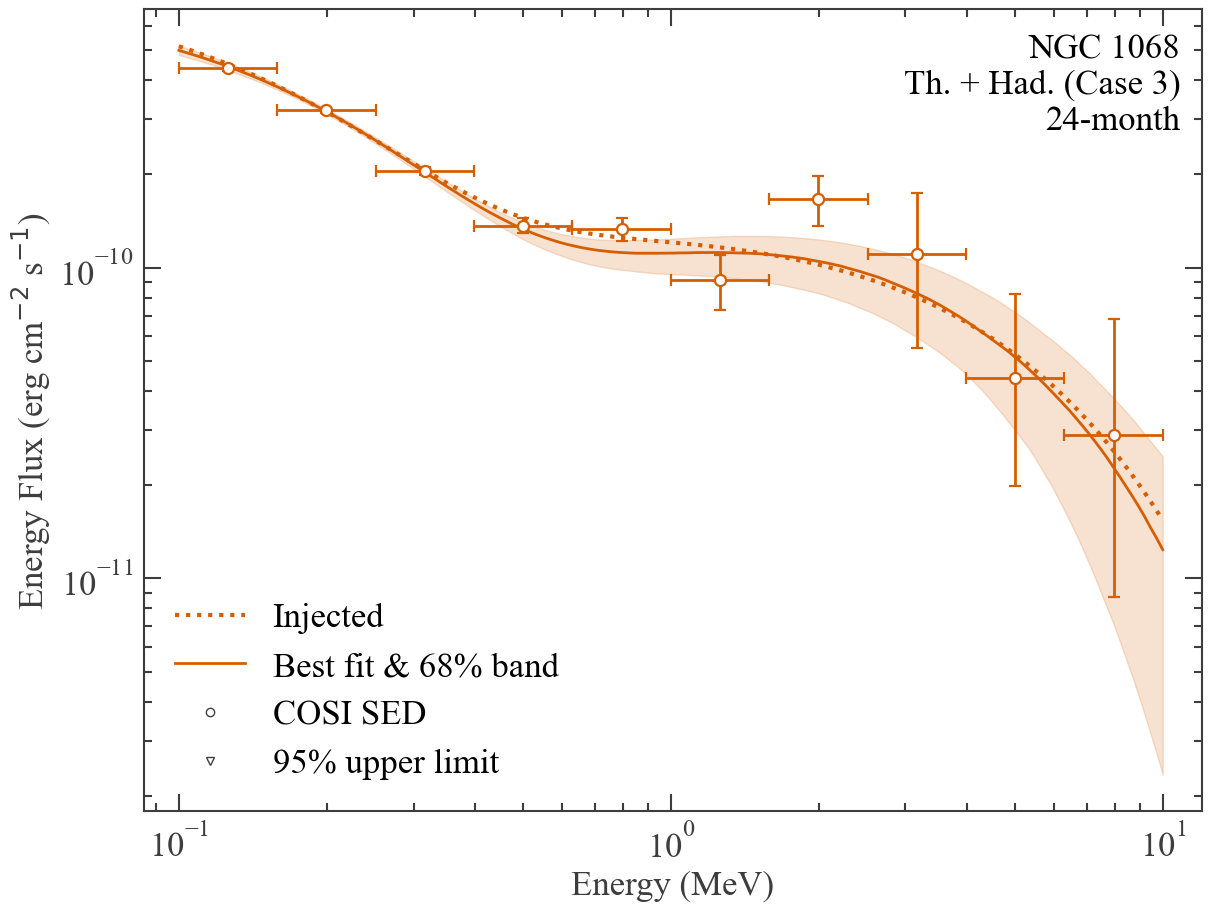

In [14]:
fig_representative, ax_representative = plot_sed_dataframe(
    representative_sed, PLOT_DIR / "NGC1068_Case3_CPL_CPL_128_24Months_SED_RepresentativeMedianDataset.pdf",
)
plt.show()


### Plot B — 300-seed median SED

SED values and TS classification use the bin-by-bin ensemble medians.


Saved: /Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/Papers/AGN_Corona_EC_Overleaf/Plots/Fluctuate_True/NGC1068_Case3_CPL_CPL_128_24Months_SED_300SeedMedianSED.pdf


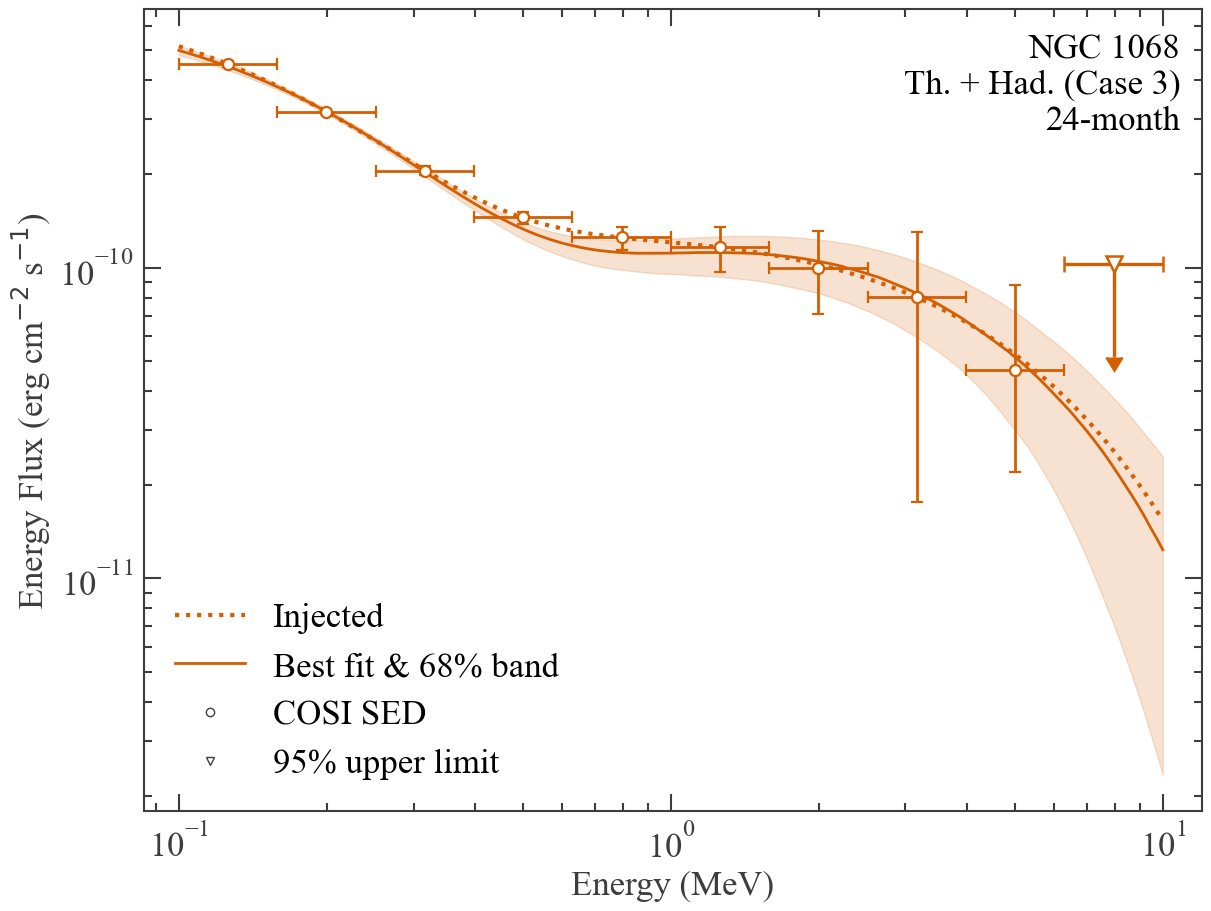

In [15]:
fig_ensemble, ax_ensemble = plot_sed_dataframe(
    ensemble_sed, None,  # Plot B is displayed but intentionally not saved.
)
plt.show()
